# COMP 1844 Coursework: Transport Network Graphs

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    'font.size': 10,
    'figure.dpi': 120,
})


def draw_graph(G, pos, line_definitions, title, label_offsets=None):
    """Reusable renderer for the schematic-style transport diagrams used in
    Task 1 and Task 2, so both tasks share one consistent visual style.

    label_offsets: optional dict {station_name: (dx_pts, dy_pts, ha, va)}
    to control where each station's name label sits relative to its node
    (dx/dy in points, ha/va = horizontal/vertical text alignment). Stations
    not listed fall back to the default diagonal (upper-right) placement.
    """
    fig, ax = plt.subplots(figsize=(12, 9))

    for line_name, (edges, color) in line_definitions.items():
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edges,
            width=4,
            edge_color=color,
            alpha=0.85,
            ax=ax,
            label=line_name,
        )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=280,
        node_color='lightgray',
        edgecolors='black',
        linewidths=1,
        ax=ax,
    )

    if label_offsets is None:
        label_offsets = {}
    default_offset = (8, 8, 'left', 'bottom')  # diagonal, upper-right

    for node, (x, y) in pos.items():
        dx, dy, ha, va = label_offsets.get(node, default_offset)
        ax.annotate(
            node,
            xy=(x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            ha=ha,
            va=va,
            fontsize=9,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85, edgecolor='none'),
            zorder=6,
        )

    edge_labels = nx.get_edge_attributes(G, 'distance')
    formatted_edge_labels = {edge: f"{dist:.2f} km" for edge, dist in edge_labels.items()}
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=formatted_edge_labels,
        font_size=8,
        label_pos=0.5,
        bbox=dict(fc='white', alpha=0.85, edgecolor='none'),
        ax=ax,
    )

    ax.margins(0.18, 0.15)

    ax.legend(loc='lower right', title='Key', fontsize=10, title_fontsize=11,
              frameon=True, edgecolor='black', fancybox=False, borderpad=1)

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    fig.tight_layout()
    plt.show()


## Task 1: 

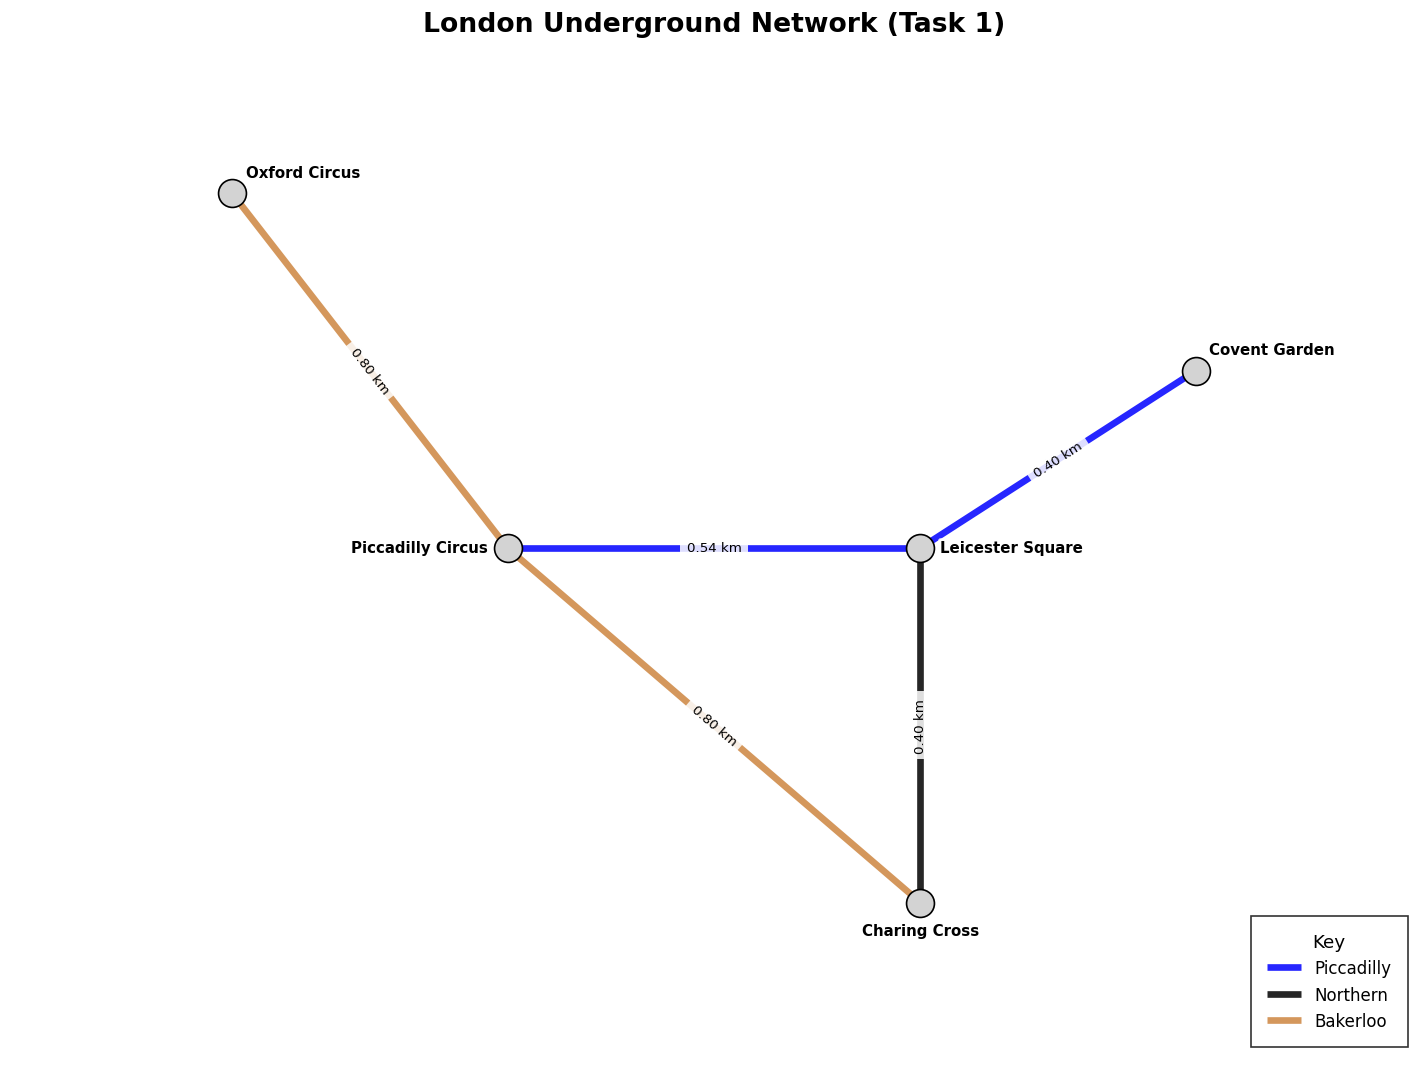

In [ ]:
G = nx.Graph()

edges_data = [
    # (station_u, station_v, distance_km)
    ("Oxford Circus",     "Piccadilly Circus", 0.80),   # a - 1/2 mile walking route
    ("Piccadilly Circus", "Charing Cross",      0.80),   # b - 1/2 mile walking route
    ("Leicester Square",  "Charing Cross",      0.40),   # c - 1/4 mile walking route
    ("Piccadilly Circus", "Leicester Square",   0.54),   # d - 1/3 mile walking route
    ("Leicester Square",  "Covent Garden",      0.40),   # e - 1/4 mile walking route
]

for u, v, dist in edges_data:
    G.add_edge(u, v, distance=dist)


pos = {
    "Oxford Circus":     (0, 4),
    "Piccadilly Circus": (1, 2),
    "Charing Cross":     (2.5, 0),
    "Leicester Square":  (2.5, 2),
    "Covent Garden":     (3.5, 3),
}


task1_lines = {
    "Piccadilly": ([("Piccadilly Circus", "Leicester Square"),
                     ("Leicester Square", "Covent Garden")], "blue"),
    "Northern":   ([("Leicester Square", "Charing Cross")], "black"),
    "Bakerloo":   ([("Oxford Circus", "Piccadilly Circus"),
                     ("Piccadilly Circus", "Charing Cross")], "peru"),
}


task1_label_offsets = {
    "Charing Cross":     (0, -12, "center", "top"),
    "Leicester Square":  (12, 0, "left", "center"),
    "Piccadilly Circus": (-12, 0, "right", "center"),
}

draw_graph(G, pos, task1_lines, "London Underground Network (Task 1)",
           label_offsets=task1_label_offsets)


## Task 2:


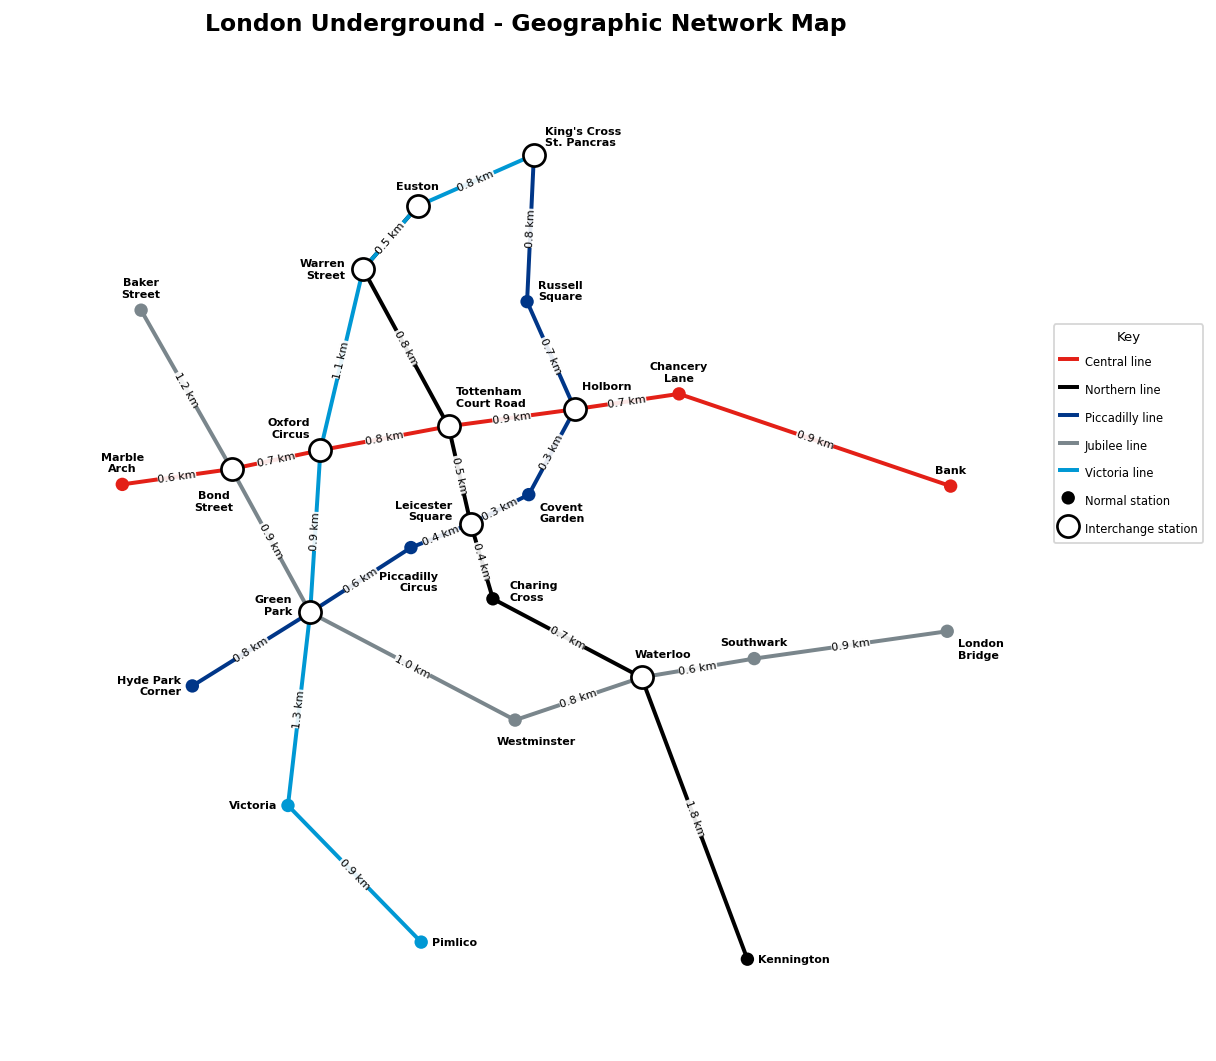

In [ ]:
line_definitions = {
    "Central line": [
        ("Marble Arch", "Bond Street", 0.6),
        ("Bond Street", "Oxford Circus", 0.7),
        ("Oxford Circus", "Tottenham Court Road", 0.8),
        ("Tottenham Court Road", "Holborn", 0.9),
        ("Holborn", "Chancery Lane", 0.7),
        ("Chancery Lane", "Bank", 0.9),
    ],
    "Northern line": [
        ("Euston", "Warren Street", 0.5),
        ("Warren Street", "Tottenham Court Road", 0.8),
        ("Tottenham Court Road", "Leicester Square", 0.5),
        ("Leicester Square", "Charing Cross", 0.4),
        ("Charing Cross", "Waterloo", 0.7),
        ("Waterloo", "Kennington", 1.8),
    ],
    "Piccadilly line": [
        ("King's Cross", "Russell Square", 0.8),
        ("Russell Square", "Holborn", 0.7),
        ("Holborn", "Covent Garden", 0.3),
        ("Covent Garden", "Leicester Square", 0.3),
        ("Leicester Square", "Piccadilly Circus", 0.4),
        ("Piccadilly Circus", "Green Park", 0.6),
        ("Green Park", "Hyde Park Corner", 0.8),
    ],
    "Jubilee line": [
        ("Baker Street", "Bond Street", 1.2),
        ("Bond Street", "Green Park", 0.9),
        ("Green Park", "Westminster", 1.0),
        ("Westminster", "Waterloo", 0.8),
        ("Waterloo", "Southwark", 0.6),
        ("Southwark", "London Bridge", 0.9),
    ],
    "Victoria line": [
        ("King's Cross", "Euston", 0.8),
        ("Euston", "Warren Street", 0.5),
        ("Warren Street", "Oxford Circus", 1.1),
        ("Oxford Circus", "Green Park", 0.9),
        ("Green Park", "Victoria", 1.3),
        ("Victoria", "Pimlico", 0.9),
    ]
}

line_colors = {
    "Central line": "#E32017",
    "Northern line": "#000000",
    "Piccadilly line": "#003688",
    "Jubilee line": "#7A868C",
    "Victoria line": "#0098D4",
}


pos2 = {
    "Marble Arch": (-1.16, -0.20),
    "Bond Street": (-0.52, -0.11),
    "Oxford Circus": (0.00, 0.00),
    "Tottenham Court Road": (0.75, 0.14),
    "Holborn": (1.49, 0.24),
    "Chancery Lane": (2.10, 0.33),
    "Bank": (3.69, -0.21),
    "Baker Street": (-1.05, 0.82),
    "Warren Street": (0.25, 1.06),
    "Euston": (0.57, 1.43),
    "King's Cross": (1.25, 1.73),
    "Russell Square": (1.21, 0.87),
    "Covent Garden": (1.22, -0.26),
    "Leicester Square": (0.88, -0.43),
    "Piccadilly Circus": (0.53, -0.57),
    "Green Park": (-0.06, -0.95),
    "Hyde Park Corner": (-0.75, -1.38),
    "Charing Cross": (1.01, -0.87),
    "Westminster": (1.14, -1.58),
    "Victoria": (-0.19, -2.08),
    "Pimlico": (0.59, -2.88),       
    "Waterloo": (1.88, -1.33),
    "Southwark": (2.54, -1.22),
    "London Bridge": (3.67, -1.06),
    "Kennington": (2.50, -2.98),
}


station_label_offsets = {
    "King's Cross": (6, 4, "left", "bottom"),
    "Euston": (0, 8, "center", "bottom"),
    "Warren Street": (-10, 0, "right", "center"),
    "Baker Street": (0, 6, "center", "bottom"),
    "Russell Square": (6, 0, "left", "bottom"),
    "Oxford Circus": (-6, 6, "right", "bottom"),
    "Bond Street": (-10, -12, "center", "top"),
    "Marble Arch": (0, 6, "center", "bottom"),
    "Tottenham Court Road": (4, 10, "left", "bottom"),
    "Holborn": (4, 10, "left", "bottom"),
    "Chancery Lane": (0, 6, "center", "bottom"),
    "Bank": (0, 6, "center", "bottom"),
    "Covent Garden": (6, -4, "left", "top"),
    "Leicester Square": (-10, 13, "right", "top"),
    "Piccadilly Circus": (15, -13, "right", "top"),
    "Green Park": (-10, 4, "right", "center"),
    "Hyde Park Corner": (-6, 0, "right", "center"),
    "Charing Cross": (9, 10, "left", "top"),
    "Westminster": (-10, -9, "left", "top"),
    "Victoria": (-6, 0, "right", "center"),
    "Pimlico": (6, 0, "left", "center"),
    "Waterloo": (-4, 10, "left", "bottom"),
    "Southwark": (0, 6, "center", "bottom"),
    "London Bridge": (6, -4, "left", "top"),
    "Kennington": (6, 0, "left", "center"),
}

station_display_labels = {
    "Tottenham Court Road": "Tottenham\nCourt Road",
    "Leicester Square": "Leicester\nSquare",
    "Piccadilly Circus": "Piccadilly\nCircus",
    "Charing Cross": "Charing\nCross",
    "London Bridge": "London\nBridge",
    "King's Cross": "King's Cross\nSt. Pancras",
    "Warren Street": "Warren\nStreet",
    "Oxford Circus": "Oxford\nCircus",
    "Green Park": "Green\nPark",
    "Marble Arch": "Marble\nArch",
    "Bond Street": "Bond\nStreet",
    "Chancery Lane": "Chancery\nLane",
    "Baker Street": "Baker\nStreet",
    "Hyde Park Corner": "Hyde Park\nCorner",
    "Covent Garden": "Covent\nGarden",
    "Russell Square": "Russell\nSquare",
}

def build_station_lines(line_definitions):
    station_lines = {}
    for line_name, edges in line_definitions.items():
        for start, end, _ in edges:
            station_lines.setdefault(start, set()).add(line_name)
            station_lines.setdefault(end, set()).add(line_name)
    return station_lines

def build_task2_graph():
    G = nx.Graph()
    for line_name, edges in line_definitions.items():
        for start, end, distance in edges:
            G.add_edge(start, end, distance=distance, line=line_name)
    return G

def draw_medium_tube_route():
    station_lines = build_station_lines(line_definitions)
    G = build_task2_graph()
    fig, ax = plt.subplots(figsize=(11, 8), dpi=130)

    ax.set_title("London Underground - Geographic Network Map", fontsize=13, fontweight="bold", pad=15)

    
    for line_name, edges in line_definitions.items():
        path = [edges[0][0]] + [end for _, end, _ in edges]
        xs = [pos2[station][0] for station in path]
        ys = [pos2[station][1] for station in path]
        ax.plot(
            xs, ys,
            color=line_colors[line_name],
            linewidth=2.2, 
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=1,
            label=line_name,
        )

    
    for start, end, distance in [(u, v, d) for edges in line_definitions.values() for u, v, d in edges]:
        x1, y1 = pos2[start]
        x2, y2 = pos2[end]
        
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{distance:.1f} km",
            fontsize=6.2,
            ha="center",
            va="center",
            rotation=angle,                     
            rotation_mode="anchor",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0.12),
            zorder=6,
        )

    # (Interchange vs Normal)
    for station, (x, y) in pos2.items():
        lines_at_station = list(station_lines[station])
        station_color = line_colors[lines_at_station[0]]
        
        if len(lines_at_station) > 1:
            ax.scatter([x], [y], s=150, facecolors="white", edgecolors="black", linewidths=1.5, zorder=5)
        else:
            ax.scatter([x], [y], s=55, facecolors=station_color, edgecolors="none", linewidths=0, zorder=5)

    # Tên các ga
    for station, (x, y) in pos2.items():
        dx, dy, ha, va = station_label_offsets[station]
        ax.annotate(
            station_display_labels.get(station, station),
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=6.2,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.10),
            zorder=7,
        )

    #Key
    line_handles = [
        ax.plot([], [], color=line_colors[line_name], linewidth=2.2, label=line_name)[0]
        for line_name in line_definitions
    ]
    
    normal_key = ax.scatter([], [], s=55, facecolors="#000000", edgecolors="none", linewidths=0, label="Normal station")
    interchange_key = ax.scatter([], [], s=150, facecolors="white", edgecolors="black", linewidths=1.5, label="Interchange station")
    
    ax.legend(
        handles=line_handles + [normal_key, interchange_key],
        title="Key",
        loc="center left",
        bbox_to_anchor=(1.01, 0.62),
        frameon=True,
        fontsize=6.4,
        title_fontsize=7.4,
        borderpad=0.50,
        labelspacing=0.86,
        handlelength=1.5,
        handleheight=2.0,
        handletextpad=0.7,
    )

    ax.set_xlim(-1.8, 4.2)
    ax.set_ylim(-3.5, 2.3)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout(rect=[0, 0, 0.82, 1], pad=0.12)
    plt.show()
    return G

G2 = draw_medium_tube_route()

## Task 3: 

In [5]:
edge_data = [
    {'Station 1': u, 'Station 2': v, 'Line': d['line'], 'Distance (km)': d['distance']}
    for u, v, d in G2.edges(data=True)
]

edge_df = pd.DataFrame(edge_data).sort_values('Distance (km)').reset_index(drop=True)


metrics = pd.Series(
    {
        'Total network length (km)': round(edge_df['Distance (km)'].sum(), 3),
        'Average distance between stations (km)': round(edge_df['Distance (km)'].mean(), 3),
        'Standard deviation of distances (km)': round(edge_df['Distance (km)'].std(ddof=0), 3),
    }
)

print('Task 3 metrics:')
print(metrics.to_string())

print('\nEdge distance data for Task 3:')
print(edge_df.to_string())

Task 3 metrics:
Total network length (km)                 23.600
Average distance between stations (km)     0.787
Standard deviation of distances (km)       0.303

Edge distance data for Task 3:
               Station 1             Station 2             Line  Distance (km)
0                Holborn         Covent Garden  Piccadilly line            0.3
1       Leicester Square         Covent Garden  Piccadilly line            0.3
2       Leicester Square         Charing Cross    Northern line            0.4
3       Leicester Square     Piccadilly Circus  Piccadilly line            0.4
4                 Euston         Warren Street    Victoria line            0.5
5   Tottenham Court Road      Leicester Square    Northern line            0.5
6               Waterloo             Southwark     Jubilee line            0.6
7            Marble Arch           Bond Street     Central line            0.6
8      Piccadilly Circus            Green Park  Piccadilly line            0.6
9              